In [82]:
%load_ext autoreload
%autoreload 2

from utils.data_utils import MnistDataHelper
from os.path import join

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [83]:
input_path = './input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

mnist_dataloader = MnistDataHelper(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train = np.array(x_train) 
x_test = np.array(x_test)

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train / x_train.max()
x_test = x_test / x_test.max()

x_train.shape, x_test.shape

((60000, 784), (10000, 784))

## Building the Networks

In [84]:
class Layer:
    def __init__(self, weights, biases, tie_layer=None):
        self.weights = weights
        self.biases = biases
        self.tie_layer = tie_layer
        self.tie_w_grad = None
        self.last_input = None
        self.w_grad = None
        self.b_grad = None
        
    def clip_grad(self, grad, clip_value=10.0):
        norm = np.linalg.norm(grad)
        if norm > clip_value:
            grad = grad * (clip_value / norm)
            
        return grad
    
    def forward(self, input):
        self.last_input = input
        dot_product = input @ self.weights
        return dot_product + self.biases
    
    def backward(self, output_error, batch_size):
        w_grad = self.last_input.T @ output_error / batch_size
        
        if self.tie_layer is not None:
            self.tie_layer.tie_w_grad = w_grad
        elif self.tie_w_grad  is not None:
            w_grad = np.add(w_grad, self.tie_w_grad.T)
        
        self.w_grad = self.clip_grad(w_grad)
        self.b_grad = self.clip_grad(np.mean(output_error, axis=0))
        
        return output_error @ self.weights.T
    
class ReluLayer(Layer):
    def __init__(self, weights, biases, tie_layer=None):
        super().__init__(weights, biases, tie_layer)
        self.last_linear_output = None

    def relu(self, input):
        return np.maximum(0, input)
    
    def forward(self, input):
        linear_output = super().forward(input)
        self.last_linear_output = linear_output
        return self.relu(linear_output)
    
    def backward(self, output_error, batch_size):
        relu_grad = output_error * (self.last_linear_output > 0)
        input_error = super().backward(relu_grad, batch_size)
        return input_error

class SigmoidLayer(Layer):
    def __init__(self, weights, biases, tie_layer=None):
        super().__init__(weights, biases, tie_layer)
    
    def sigmoid(self, input):
        return 1 / (1 + np.exp(-input))
    
    def forward(self, input):
        linear_output = super().forward(input)
        return self.sigmoid(linear_output)

In [85]:
def initialize_layers(input_size, hidden1_size, hidden2_size, latent_size):
    hidden1_weights = np.random.normal(0, np.sqrt(2.0 / input_size), size=(input_size, hidden1_size))
    hidden1_biases = np.zeros(shape=(hidden1_size,))
    hidden1_layer = ReluLayer(hidden1_weights, hidden1_biases)

    hidden2_weights = np.random.normal(0, np.sqrt(2.0 / hidden1_size), size=(hidden1_size, hidden2_size))
    hidden2_biases = np.zeros(shape=(hidden2_size,))
    hidden2_layer = ReluLayer(hidden2_weights, hidden2_biases)

    latent_weights = np.random.normal(0, np.sqrt(2.0 / hidden2_size), size=(hidden2_size, latent_size))
    latent_biases = np.zeros(shape=(latent_size,))
    latent_layer = ReluLayer(latent_weights, latent_biases)
    
    hidden3_weights = latent_weights.T
    hidden3_biases = np.zeros(shape=(hidden2_size,))
    hidden3_layer = ReluLayer(hidden3_weights, hidden3_biases, latent_layer)
    
    hidden4_weights = hidden2_weights.T
    hidden4_biases = np.zeros(shape=(hidden1_size,))
    hidden4_layer = ReluLayer(hidden4_weights, hidden4_biases, hidden2_layer)
    
    output_weights = hidden1_weights.T
    output_biases = np.zeros(shape=(input_size,))
    output_layer = SigmoidLayer(output_weights, output_biases, hidden1_layer)

    return [hidden1_layer, hidden2_layer, latent_layer, hidden3_layer, hidden4_layer, output_layer]

In [86]:
class Network:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, input):
        outputs = []
        
        for layer in self.layers:
            output = layer.forward(input)
            outputs.append(output)
            input = output
            
        return outputs

    def backward(self, output_error, batch_size):
        acc_grad = output_error
        
        for layer in reversed(self.layers):
            acc_grad = layer.backward(acc_grad, batch_size)

    def update_parameters(self, learning_rate):
        for layer in self.layers:
            if layer.tie_layer is not None:
                layer.weights = layer.tie_layer.weights.T
            else:
                layer.weights -= layer.w_grad * learning_rate
            
            layer.biases -= layer.b_grad * learning_rate

In [87]:
network1 = Network(initialize_layers(784, 256, 64, 36))
network2 = Network(initialize_layers(784, 256, 64, 16))
network3 = Network(initialize_layers(784, 256, 64, 9))
network4 = Network(initialize_layers(784, 256, 64, 4))

In [88]:
def compute_loss(output_error):
    return np.mean(output_error ** 2)

## Training the Networks

In [89]:
def train(x_train, network, learning_rate, epochs, batch_size, adaptive_learning=True):
    num_samples = x_train.shape[0]
    epoch_losses = []
    epochs_since_update = 0
    
    for epoch in range(epochs):
        total_loss = 0
        
        for i in range(0, num_samples, batch_size):
            batch_inputs = x_train[i:i+batch_size]
            batch_targets = batch_inputs
            
            outputs = network.forward(batch_inputs)
            
            output_error = outputs[-1] - batch_targets
            
            loss = compute_loss(output_error)
            total_loss += loss
            
            network.backward(output_error, batch_size)
            network.update_parameters(learning_rate)
            
        avg_loss = total_loss / num_samples
        
        if adaptive_learning and epochs_since_update > 5:
            loss_percentage = avg_loss / epoch_losses[-1]
            
            if loss_percentage >= 0.95:
                learning_rate *= 0.95
                epochs_since_update = 0
                    
        epoch_losses.append(avg_loss)
        epochs_since_update += 1
        
        print(f'Epoch {epoch + 1}/{epochs} completed | Avg. Loss: {avg_loss:.10f} | Learning Rate: {learning_rate:.8f}')

In [90]:
hyperparameters = {
    "learning_rate": 0.01,
    "epochs": 50,
    "batch_size": 32
}

In [91]:
train(x_train, network1, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 1/50 completed | Avg. Loss: 0.0010112945 | Learning Rate: 0.01000000
Epoch 2/50 completed | Avg. Loss: 0.0005803360 | Learning Rate: 0.01000000
Epoch 3/50 completed | Avg. Loss: 0.0004854134 | Learning Rate: 0.01000000
Epoch 4/50 completed | Avg. Loss: 0.0004341654 | Learning Rate: 0.01000000
Epoch 5/50 completed | Avg. Loss: 0.0003992179 | Learning Rate: 0.01000000
Epoch 6/50 completed | Avg. Loss: 0.0003726546 | Learning Rate: 0.01000000
Epoch 7/50 completed | Avg. Loss: 0.0003508297 | Learning Rate: 0.01000000
Epoch 8/50 completed | Avg. Loss: 0.0003326378 | Learning Rate: 0.01000000
Epoch 9/50 completed | Avg. Loss: 0.0003173922 | Learning Rate: 0.00950000
Epoch 10/50 completed | Avg. Loss: 0.0002987877 | Learning Rate: 0.00950000
Epoch 11/50 completed | Avg. Loss: 0.0002886800 | Learning Rate: 0.00950000
Epoch 12/50 completed | Avg. Loss: 0.0002800869 | Learning Rate: 0.00950000
Epoch 13/50 completed | Avg. Loss: 0.0002726985 | Learning Rate: 0.00950000
Epoch 14/50 completed

In [92]:
train(x_train, network2, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 1/50 completed | Avg. Loss: 0.0012264790 | Learning Rate: 0.01000000
Epoch 2/50 completed | Avg. Loss: 0.0007447697 | Learning Rate: 0.01000000
Epoch 3/50 completed | Avg. Loss: 0.0006372098 | Learning Rate: 0.01000000
Epoch 4/50 completed | Avg. Loss: 0.0005801850 | Learning Rate: 0.01000000
Epoch 5/50 completed | Avg. Loss: 0.0005415309 | Learning Rate: 0.01000000
Epoch 6/50 completed | Avg. Loss: 0.0005120608 | Learning Rate: 0.01000000
Epoch 7/50 completed | Avg. Loss: 0.0004893015 | Learning Rate: 0.00950000
Epoch 8/50 completed | Avg. Loss: 0.0004659101 | Learning Rate: 0.00950000
Epoch 9/50 completed | Avg. Loss: 0.0004512123 | Learning Rate: 0.00950000
Epoch 10/50 completed | Avg. Loss: 0.0004389185 | Learning Rate: 0.00950000
Epoch 11/50 completed | Avg. Loss: 0.0004284072 | Learning Rate: 0.00950000
Epoch 12/50 completed | Avg. Loss: 0.0004193639 | Learning Rate: 0.00950000
Epoch 13/50 completed | Avg. Loss: 0.0004117025 | Learning Rate: 0.00902500
Epoch 14/50 completed

In [93]:
train(x_train, network3, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 1/50 completed | Avg. Loss: 0.0014356785 | Learning Rate: 0.01000000
Epoch 2/50 completed | Avg. Loss: 0.0009804734 | Learning Rate: 0.01000000
Epoch 3/50 completed | Avg. Loss: 0.0008307712 | Learning Rate: 0.01000000
Epoch 4/50 completed | Avg. Loss: 0.0007578512 | Learning Rate: 0.01000000
Epoch 5/50 completed | Avg. Loss: 0.0007152228 | Learning Rate: 0.01000000
Epoch 6/50 completed | Avg. Loss: 0.0006853980 | Learning Rate: 0.01000000
Epoch 7/50 completed | Avg. Loss: 0.0006619624 | Learning Rate: 0.00950000
Epoch 8/50 completed | Avg. Loss: 0.0006390677 | Learning Rate: 0.00950000
Epoch 9/50 completed | Avg. Loss: 0.0006239135 | Learning Rate: 0.00950000
Epoch 10/50 completed | Avg. Loss: 0.0006110690 | Learning Rate: 0.00950000
Epoch 11/50 completed | Avg. Loss: 0.0006003510 | Learning Rate: 0.00950000
Epoch 12/50 completed | Avg. Loss: 0.0005910814 | Learning Rate: 0.00950000
Epoch 13/50 completed | Avg. Loss: 0.0005829302 | Learning Rate: 0.00902500
Epoch 14/50 completed

In [94]:
train(x_train, network4, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 1/50 completed | Avg. Loss: 0.0016330160 | Learning Rate: 0.01000000
Epoch 2/50 completed | Avg. Loss: 0.0012612166 | Learning Rate: 0.01000000
Epoch 3/50 completed | Avg. Loss: 0.0011547800 | Learning Rate: 0.01000000
Epoch 4/50 completed | Avg. Loss: 0.0010989924 | Learning Rate: 0.01000000
Epoch 5/50 completed | Avg. Loss: 0.0010629831 | Learning Rate: 0.01000000
Epoch 6/50 completed | Avg. Loss: 0.0010351393 | Learning Rate: 0.01000000
Epoch 7/50 completed | Avg. Loss: 0.0010124284 | Learning Rate: 0.00950000
Epoch 8/50 completed | Avg. Loss: 0.0009903168 | Learning Rate: 0.00950000
Epoch 9/50 completed | Avg. Loss: 0.0009751950 | Learning Rate: 0.00950000
Epoch 10/50 completed | Avg. Loss: 0.0009623481 | Learning Rate: 0.00950000
Epoch 11/50 completed | Avg. Loss: 0.0009514679 | Learning Rate: 0.00950000
Epoch 12/50 completed | Avg. Loss: 0.0009415038 | Learning Rate: 0.00950000
Epoch 13/50 completed | Avg. Loss: 0.0009324638 | Learning Rate: 0.00902500
Epoch 14/50 completed

## Visualizing Results

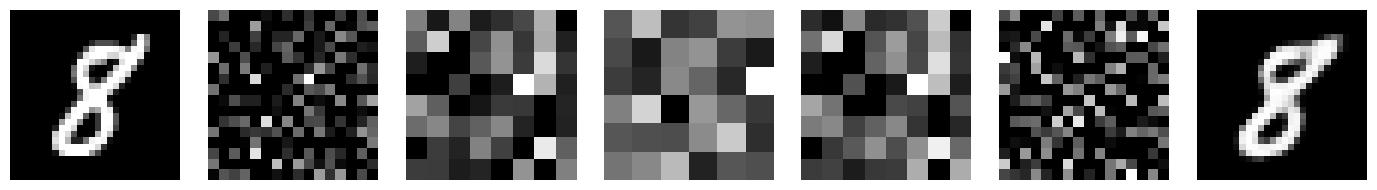

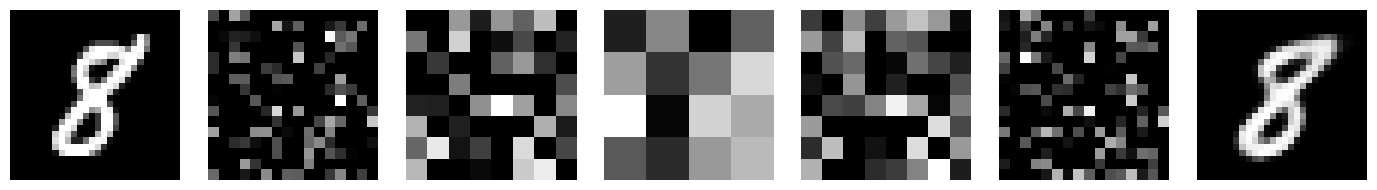

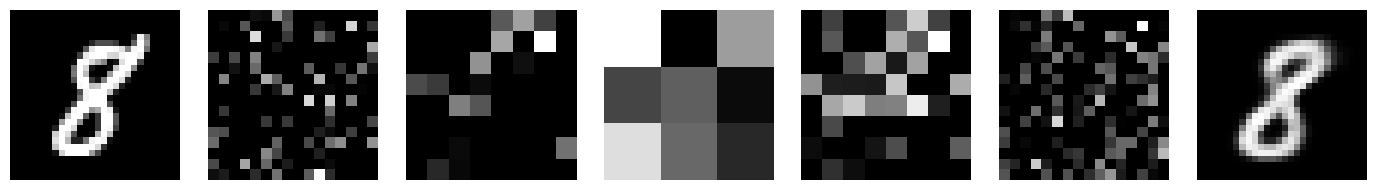

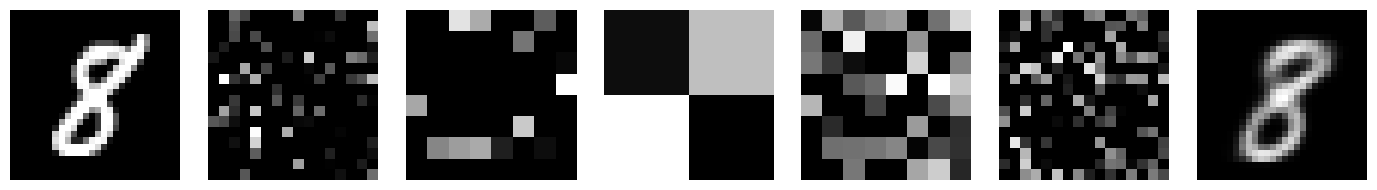

In [107]:
MnistDataHelper.plot_transformation(x_test, 1, [network1, network2, network3, network4])

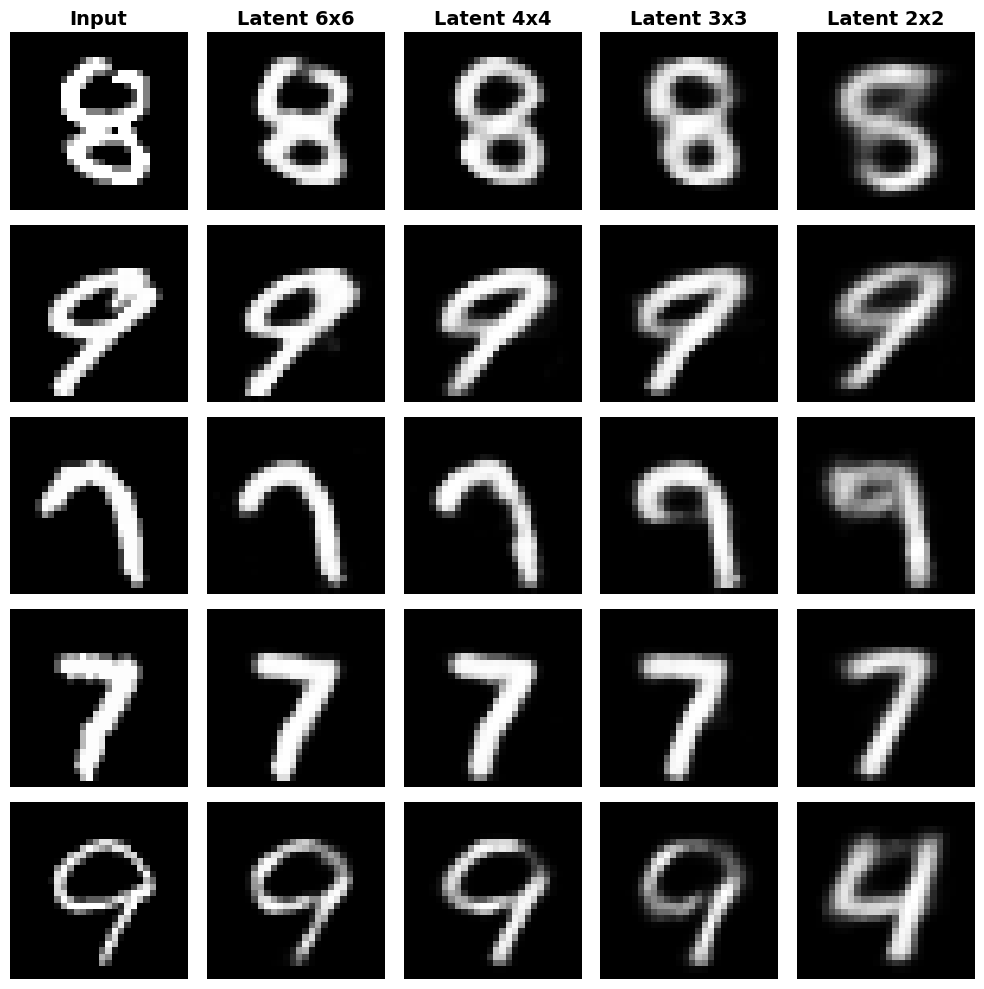

In [108]:
MnistDataHelper.plot_net_comparison(x_test, 5, [network1, network2, network3, network4], ["Latent 6x6", "Latent 4x4", "Latent 3x3", "Latent 2x2"])

In [98]:
def test(x_test, network):
    outputs = network.forward(x_test)
    
    loss = compute_loss(outputs[-1] - x_test)
    return loss.mean()


print(f"Network 1 | Mean total loss: {test(x_test, network1):.6f}")
print(f"Network 2 | Mean total loss: {test(x_test, network2):.6f}")
print(f"Network 3 | Mean total loss: {test(x_test, network3):.6f}")
print(f"Network 4 | Mean total loss: {test(x_test, network4):.6f}")

Network 1 | Mean total loss: 0.005667
Network 2 | Mean total loss: 0.010123
Network 3 | Mean total loss: 0.015934
Network 4 | Mean total loss: 0.028536
